# Phase 03: Exploratory Data Analysis (EDA)

**Objective**

The objective of this notebook is to explore the cleaned dataset to understand:

Feature distributions<br>
Relationships between variables<br>
Trends and patterns<br>
Potential outliers<br>
Correlations<br>
Insights that will guide feature engineering and clustering

**Expected Deliverables**

By the end of this notebook, we should know:

Distribution of every feature<br>
Which variables are skewed<br>
Which variables have low or high variability<br>
Which variables are strongly related<br>
Whether outliers are meaningful<br>
Which features may be engineered<br>
Which features may need transformation<br>
Which variables may dominate clustering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

eda_df = pd.read_csv("dataset\\clean_dataset.csv")

In [2]:
#Setting display option
pd.set_option("display.max_columns", None)

# Set plotting style
plt.style.use("default")
sns.set_theme(style="whitegrid")

In [3]:
print("Dataset Shape : \n")

print(f"Rows    : {eda_df.shape[0]}")
print(f"Columns : {eda_df.shape[1]}")

Dataset Shape : 

Rows    : 15489
Columns : 23


<h4>Section A: Numerical Variables</h4>

In [4]:
numerical_features = eda_df.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

print(numerical_features)

['FRUITS_VEGGIES', 'DAILY_STRESS', 'PLACES_VISITED', 'CORE_CIRCLE', 'SUPPORTING_OTHERS', 'SOCIAL_NETWORK', 'ACHIEVEMENT', 'DONATION', 'BMI_RANGE', 'TODO_COMPLETED', 'FLOW', 'DAILY_STEPS', 'LIVE_VISION', 'SLEEP_HOURS', 'LOST_VACATION', 'DAILY_SHOUTING', 'SUFFICIENT_INCOME', 'PERSONAL_AWARDS', 'TIME_FOR_PASSION', 'WEEKLY_MEDITATION', 'AGE', 'WORK_LIFE_BALANCE_SCORE']


**Univariate Analysis**

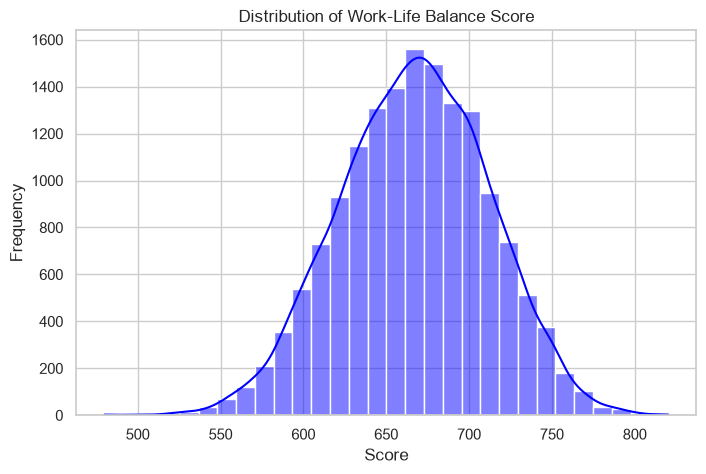

In [5]:
# 1. Univariate: Distribution of the Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(eda_df['WORK_LIFE_BALANCE_SCORE'], bins=30, kde=True, color='blue')
plt.title('Distribution of Work-Life Balance Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

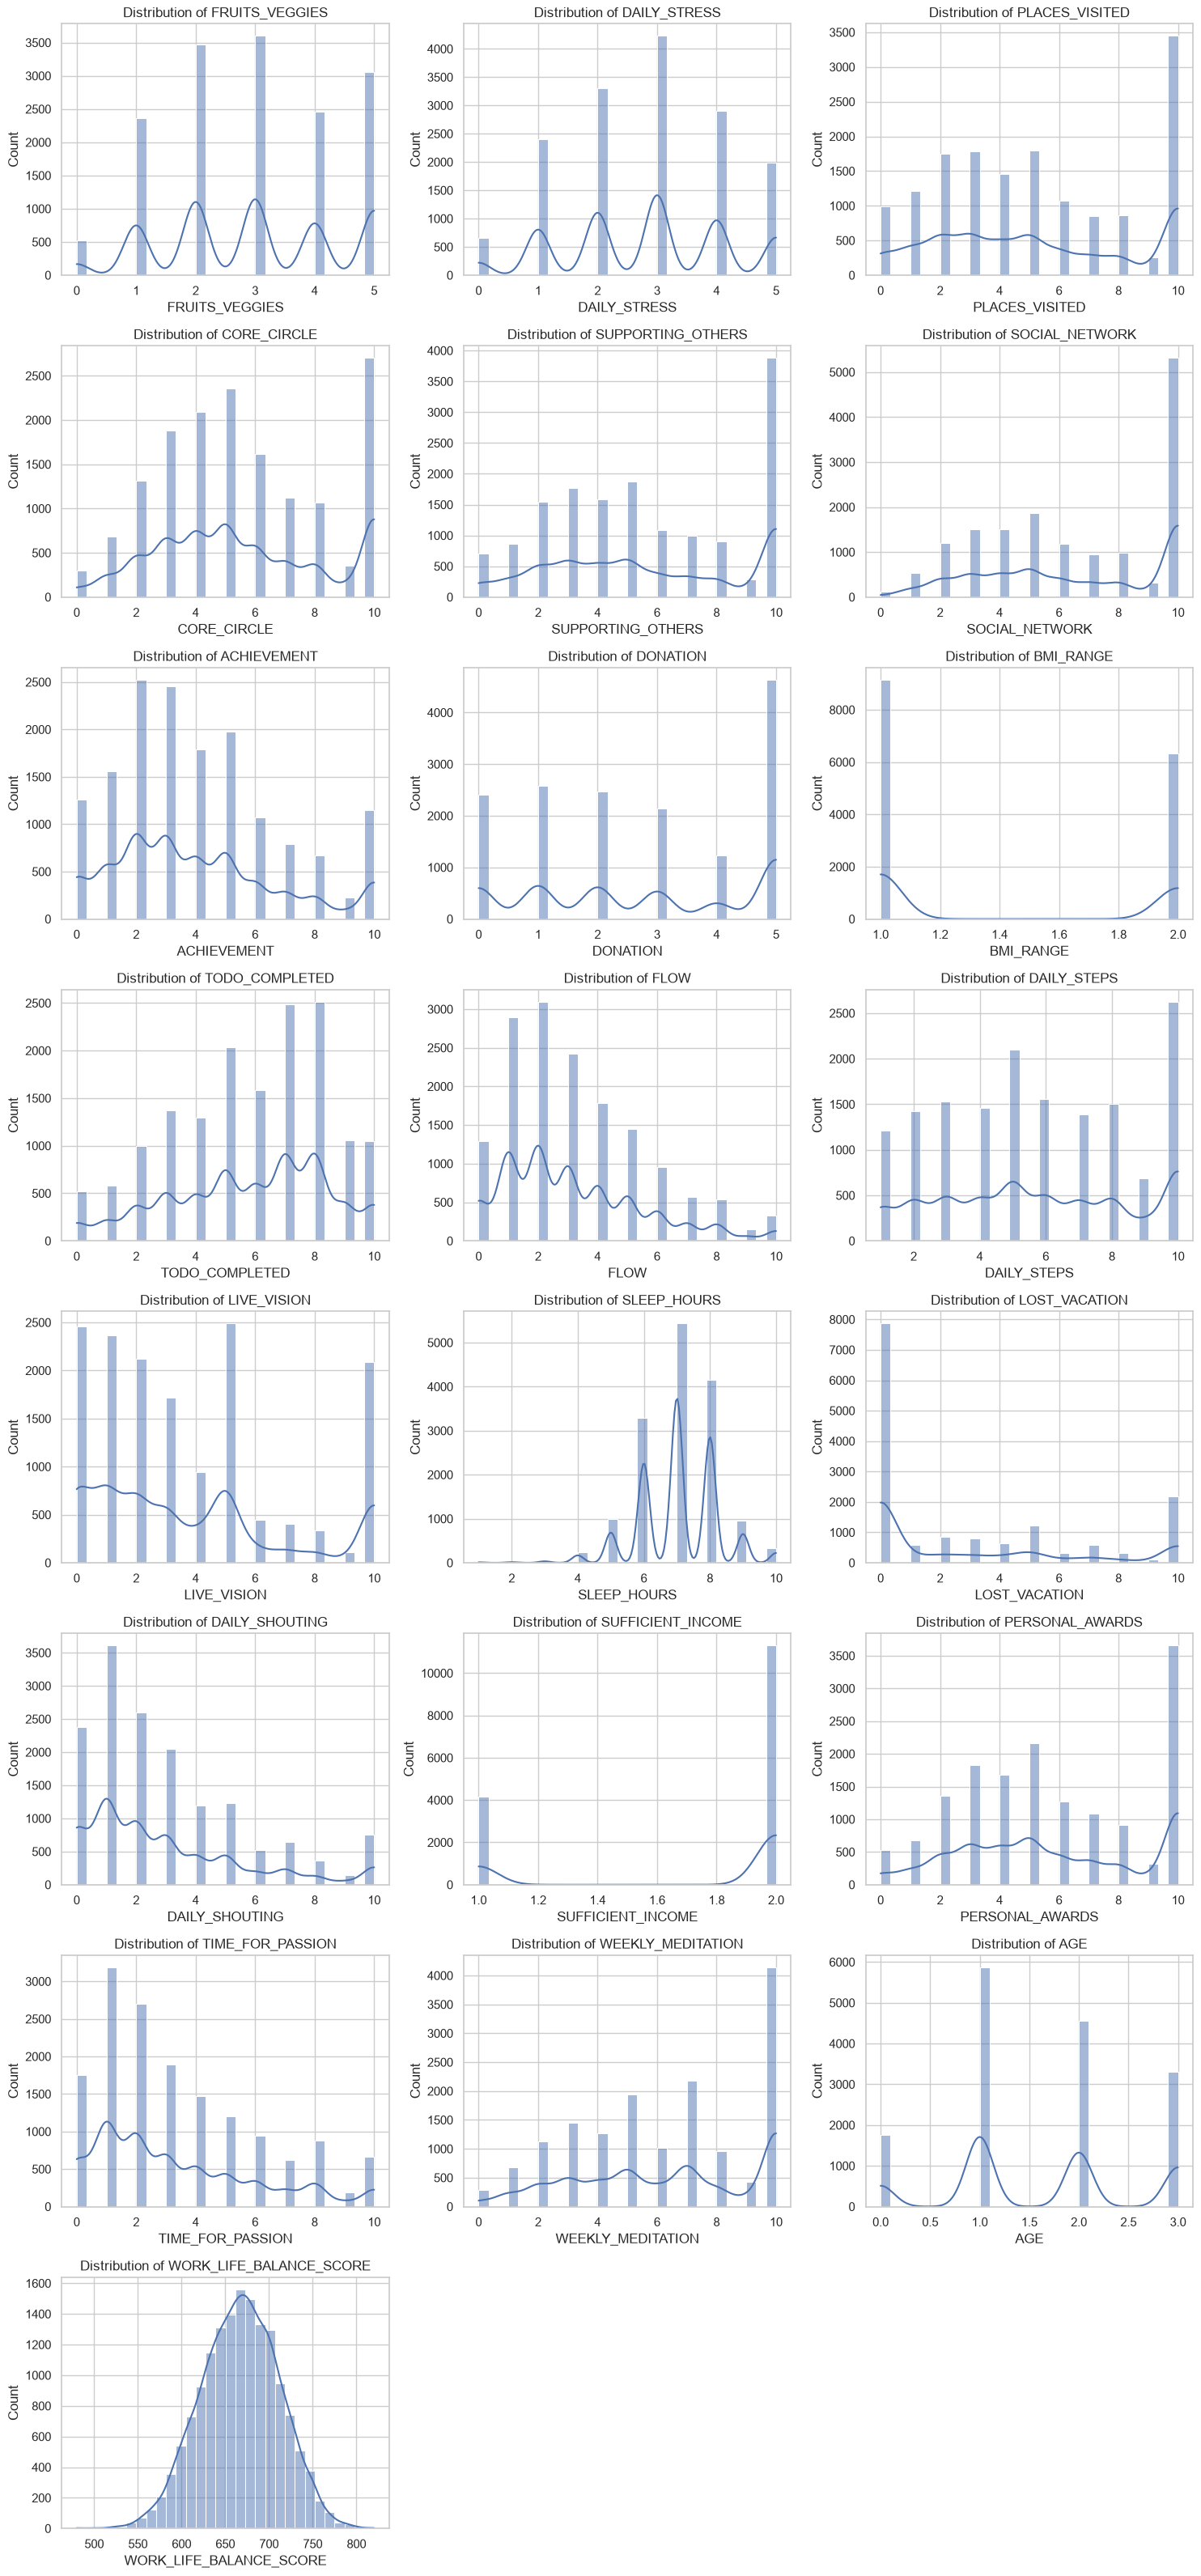

In [6]:
fig, axes = plt.subplots(8, 3, figsize=(15, 32))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(
        data=eda_df,
        x=feature,
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {feature}")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [7]:
distribution_summary = pd.DataFrame({
    "Mean": eda_df[numerical_features].mean(),
    "Median": eda_df[numerical_features].median(),
    "Std Dev": eda_df[numerical_features].std(),
    "Skewness": eda_df[numerical_features].skew(),
    "Kurtosis": eda_df[numerical_features].kurt()
})

display(distribution_summary.round(3))

,Mean,Median,Std Dev,Skewness,Kurtosis
FRUITS_VEGGIES,2.922,3.0,1.443,-0.046,-1.014
DAILY_STRESS,2.792,3.0,1.369,-0.083,-0.805
PLACES_VISITED,5.226,5.0,3.316,0.174,-1.256
CORE_CIRCLE,5.513,5.0,2.839,0.202,-0.968
SUPPORTING_OTHERS,5.619,5.0,3.244,0.055,-1.274
SOCIAL_NETWORK,6.489,6.0,3.085,-0.184,-1.365
ACHIEVEMENT,4.000,3.0,2.760,0.634,-0.353
DONATION,2.716,3.0,1.851,-0.046,-1.439
BMI_RANGE,1.409,1.0,0.492,0.370,-1.863
TODO_COMPLETED,5.750,6.0,2.623,-0.356,-0.707


# Bivariate Analysis

In [8]:
feature_pairs = [

    ("DAILY_STRESS", "SLEEP_HOURS"),

    ("DAILY_STRESS", "WORK_LIFE_BALANCE_SCORE"),

    ("DAILY_STEPS", "WORK_LIFE_BALANCE_SCORE"),

    ("TIME_FOR_PASSION", "WORK_LIFE_BALANCE_SCORE"),

    ("FLOW", "ACHIEVEMENT"),

    ("CORE_CIRCLE", "SOCIAL_NETWORK"),

    ("SUPPORTING_OTHERS", "PERSONAL_AWARDS"),

    ("WEEKLY_MEDITATION", "DAILY_STRESS"),

    ("LIVE_VISION", "ACHIEVEMENT"),

    ("AGE", "WORK_LIFE_BALANCE_SCORE"),

    ("BMI_RANGE", "DAILY_STEPS"),

    ("AGE", "DAILY_STRESS")

]

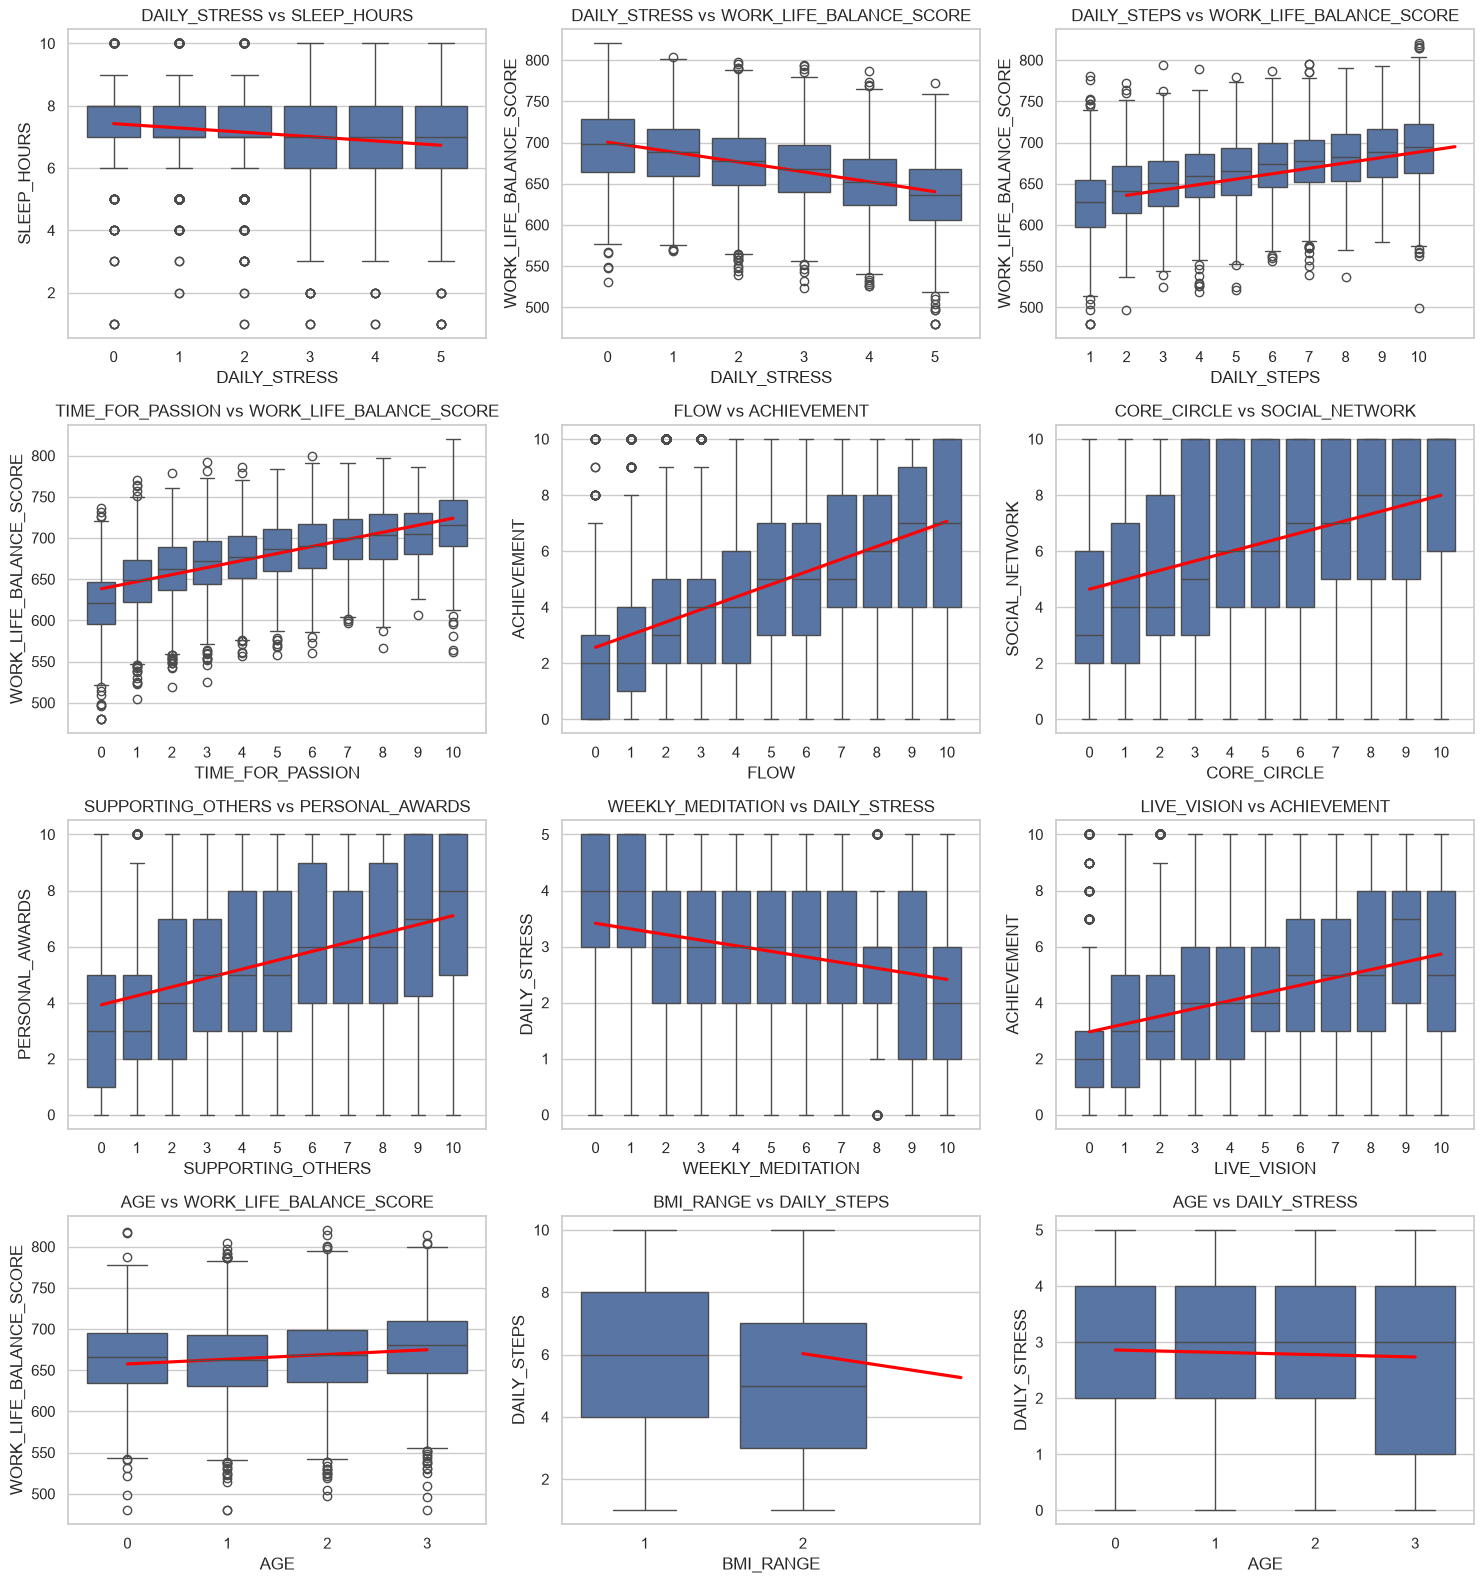

In [26]:
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, (x_feature, y_feature) in enumerate(feature_pairs):

    sns.boxplot(data=eda_df, x=x_feature, y=y_feature, ax=axes[i])
    sns.regplot(
        data=eda_df,
        x=x_feature,
        y=y_feature,
        scatter_kws={"alpha":0.4},
        line_kws={"color":"red"},
        scatter=False,
        ax=axes[i]
    )
    axes[i].set_title(f"{x_feature} vs {y_feature}")

# Hide any unused subplots if feature_pairs < 12
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Multivariate Analysis

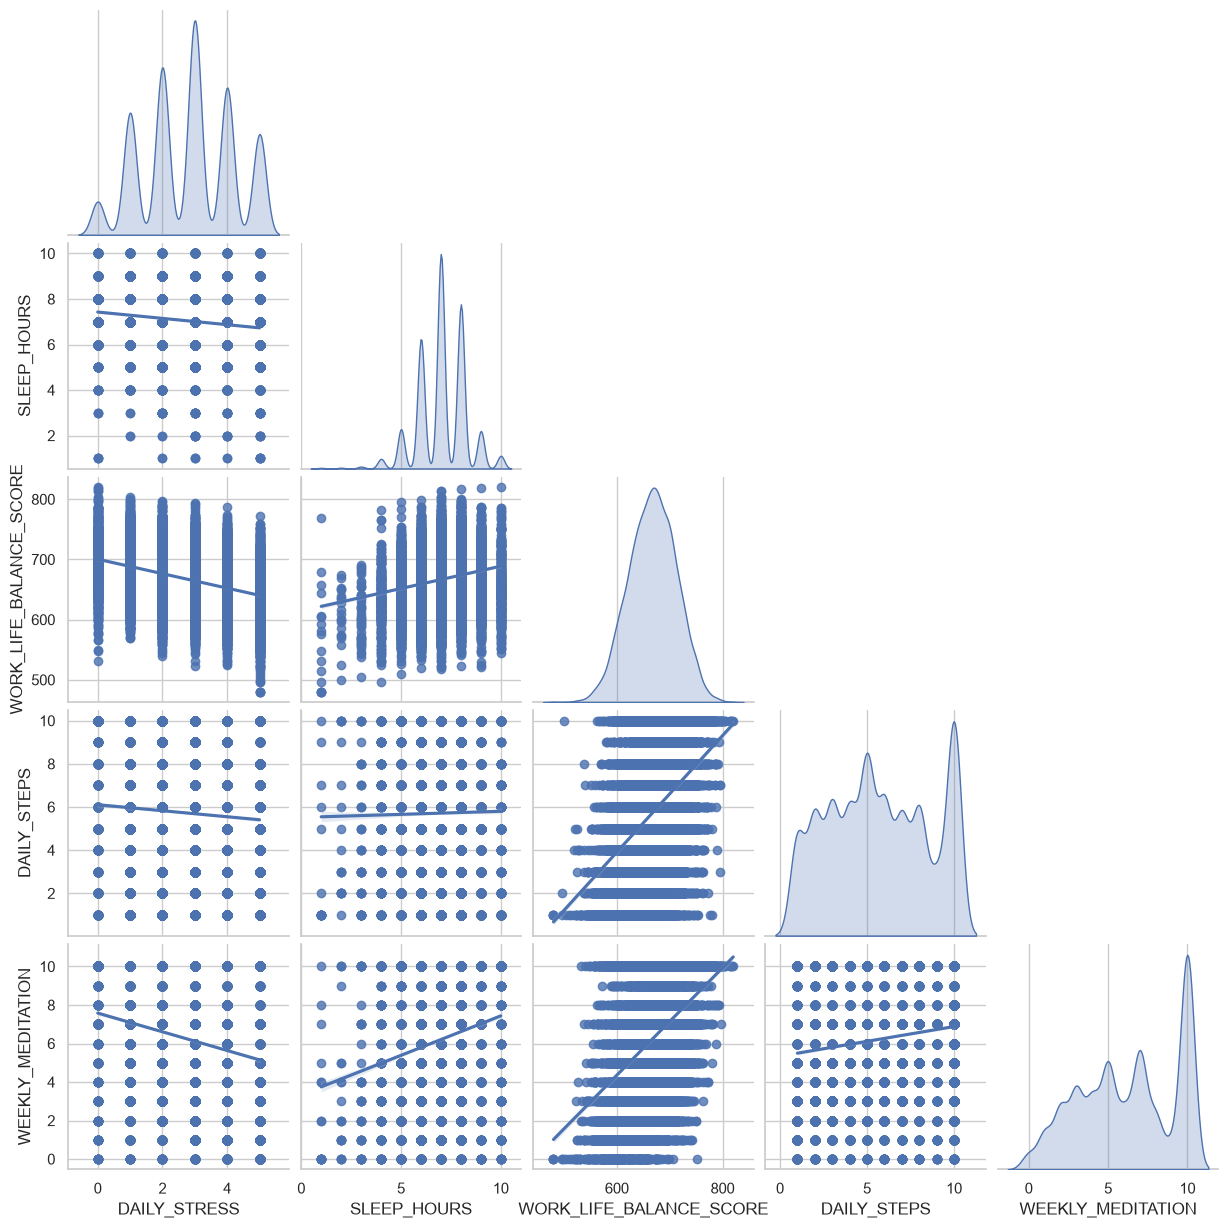

In [ ]:
selected_features = [
    "DAILY_STRESS",
    "SLEEP_HOURS",
    "WORK_LIFE_BALANCE_SCORE",
    "DAILY_STEPS",
    "WEEKLY_MEDITATION"
]

sns.pairplot(
    eda_df[selected_features],
    kind="reg",
    diag_kind="kde",
    corner=True
)

plt.show()

In [31]:
age_summary = (
    eda_df
    .groupby("AGE")
    .agg({
        "WORK_LIFE_BALANCE_SCORE": ["mean", "median", "std"],
        "DAILY_STRESS": ["mean"],
        "SLEEP_HOURS": ["mean"]
    })
)

display(age_summary)

WORK_LIFE_BALANCE_SCORE                    DAILY_STRESS SLEEP_HOURS
                       mean  median        std         mean        mean
AGE                                                                    
0                664.041572  666.00  44.084519     2.758542    7.173121
1                661.229150  662.00  43.803170     2.817470    7.103865
2                667.073013  667.85  45.336993     2.892402    6.952569
3                677.973926  680.00  45.099246     2.627647    6.969449

# Parallel cordinates

In [39]:
eda_df.head()

,FRUITS_VEGGIES,DAILY_STRESS,PLACES_VISITED,CORE_CIRCLE,SUPPORTING_OTHERS,SOCIAL_NETWORK,ACHIEVEMENT,DONATION,BMI_RANGE,TODO_COMPLETED,FLOW,DAILY_STEPS,LIVE_VISION,SLEEP_HOURS,LOST_VACATION,DAILY_SHOUTING,SUFFICIENT_INCOME,PERSONAL_AWARDS,TIME_FOR_PASSION,WEEKLY_MEDITATION,AGE,WORK_LIFE_BALANCE_SCORE,GENDER_Male
0,3,2,2,5,0,5,2,0,1,6,4,5,0,7,5,5,1,4,0,5,2,609.5,False
1,2,3,4,3,8,10,5,2,2,5,2,5,5,8,2,2,2,3,2,6,2,655.6,False
2,2,3,3,4,4,10,3,2,2,2,2,4,5,8,10,2,2,4,8,3,2,631.6,False
3,3,3,10,3,10,7,2,5,2,3,5,5,0,5,7,5,1,5,2,0,3,622.7,False
4,5,1,3,3,10,4,2,4,2,5,0,5,0,7,0,0,2,8,1,5,3,663.9,False


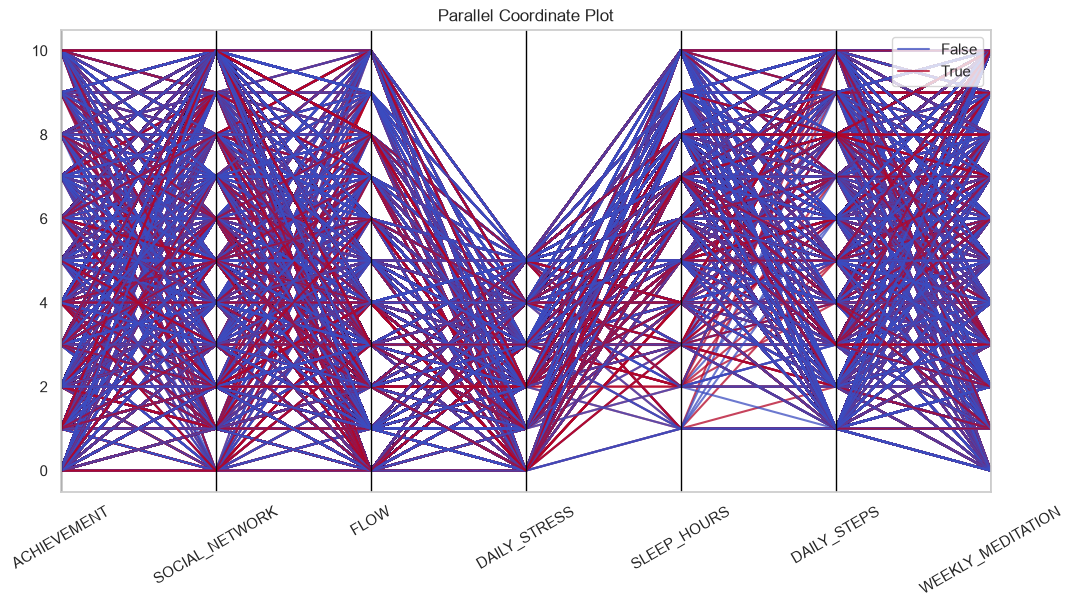

In [45]:
from matplotlib.cm import coolwarm
from pandas.plotting import parallel_coordinates

parallel_features = [
    "GENDER_Male",
    "ACHIEVEMENT",
    "SOCIAL_NETWORK",
    "FLOW",
    "DAILY_STRESS",
    "SLEEP_HOURS",
    "DAILY_STEPS",
    "WEEKLY_MEDITATION",
]

parallel_df = eda_df[parallel_features].copy()

parallel_df["GENDER_Male"] = parallel_df["GENDER_Male"].astype(str)

plt.figure(figsize=(12,6))

parallel_coordinates(
    parallel_df,
    class_column="GENDER_Male",
    colormap="coolwarm",
    alpha=0.75
)

plt.title("Parallel Coordinate Plot")

plt.xticks(rotation=30)

plt.show()


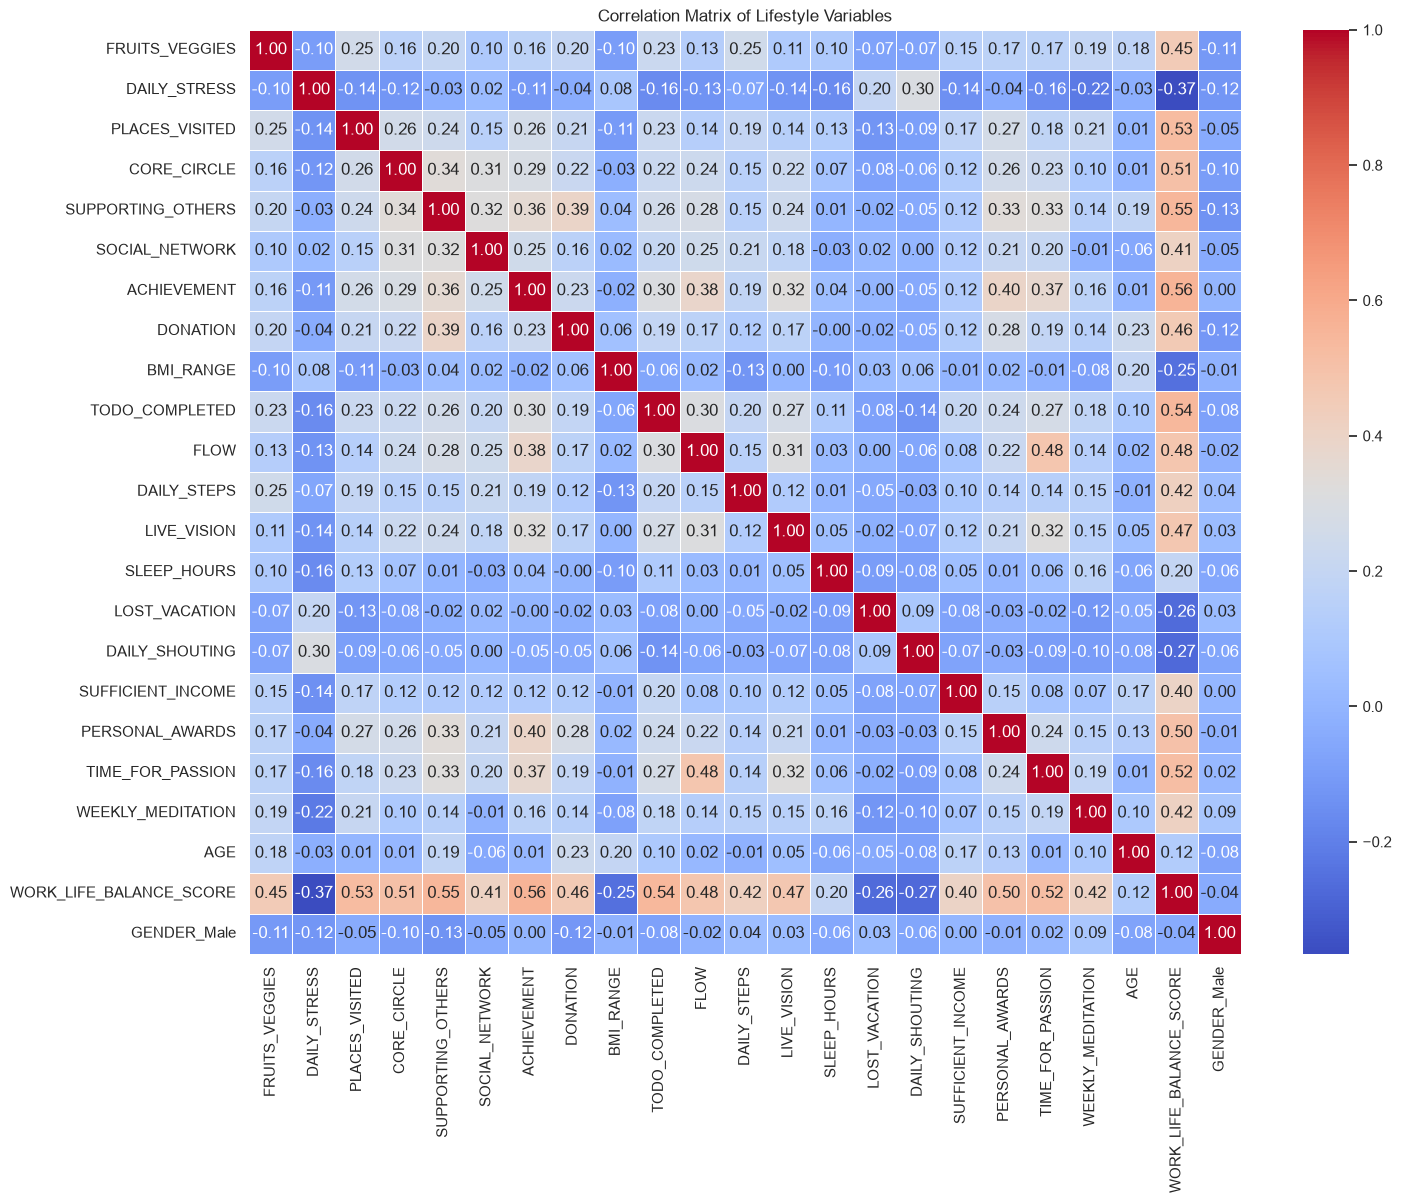

In [12]:
#Plotting the corelation matrix to show corelation between attributes

correlated = eda_df.corr()
plt.figure(figsize= (16,12))
sns.heatmap(correlated, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Lifestyle Variables')
plt.show()

<h3> Instead of creating Boxplots we are doing <b>Response Distribution Validation</b> because in this case </br>we have the data as rating scale from 0-2, 0-5, 0-10 hence we cannot plot boxplot to detect outliers </h3>

In [55]:
rating_ranges = {
    "FRUITS_VEGGIES": (0, 5),
    "DAILY_STRESS": (0, 5),
    "PLACES_VISITED": (0, 10),
    "CORE_CIRCLE": (0, 10),
    "SUPPORTING_OTHERS": (0, 10),
    "SOCIAL_NETWORK": (0, 10),
    "ACHIEVEMENT": (0, 10),
    "DONATION": (0, 5),
    "BMI_RANGE": (1, 2),
    "TODO_COMPLETED": (0, 10),
    "FLOW": (0, 10),
    "DAILY_STEPS": (1, 10),
    "LIVE_VISION": (0, 10),
    "SLEEP_HOURS": (1, 10),
    "LOST_VACATION": (0, 10),
    "DAILY_SHOUTING": (0, 10),
    "SUFFICIENT_INCOME": (1, 2),
    "PERSONAL_AWARDS": (0, 10),
    "TIME_FOR_PASSION": (0, 10),
    "WEEKLY_MEDITATION": (0, 10)
}

validation_results = []

for feature, (min_val, max_val) in rating_ranges.items():

    invalid = eda_df[
        (eda_df[feature] < min_val) |
        (eda_df[feature] > max_val)
    ]

    validation_results.append({
        "Feature": feature,
        "Expected Range": f"{min_val} - {max_val}",
        "Invalid Responses": len(invalid)
    })

validation_df = pd.DataFrame(validation_results)

display(validation_df)

,Feature,Expected Range,Invalid Responses
0,FRUITS_VEGGIES,0 - 5,0
1,DAILY_STRESS,0 - 5,0
2,PLACES_VISITED,0 - 10,0
3,CORE_CIRCLE,0 - 10,0
4,SUPPORTING_OTHERS,0 - 10,0
5,SOCIAL_NETWORK,0 - 10,0
6,ACHIEVEMENT,0 - 10,0
7,DONATION,0 - 5,0
8,BMI_RANGE,1 - 2,0
9,TODO_COMPLETED,0 - 10,0


<h3>There are no invalid responses in the dataset. <br> Now we will proceed with checking the percentage of contribution of each feature in the dataset</h3>

In [62]:
compiled_data = []

for feature in rating_ranges.keys():
    counts = (
        eda_df[feature]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
    
    # Convert the Series to a dictionary and add the feature name
    row_dict = counts.to_dict()
    row_dict['Feature'] = feature
    
    compiled_data.append(row_dict)

# 3. Create the DataFrame and clean up the layout
percentage_df = pd.DataFrame(compiled_data)

# Set the Feature name as the index
percentage_df.set_index('Feature', inplace=True)

# Sort columns numerically (0, 1, 2... instead of random order)
percentage_df = percentage_df.reindex(sorted(percentage_df.columns), axis=1)

# Fill any missing ratings with 0.0 (e.g. if a feature didn't have any '10' ratings)
percentage_df.fillna(0.0, inplace=True)

# 4. View your new clean DataFrame
display(percentage_df)


,0,1,2,3,4,5,6,7,8,9,10
Feature,,,,,,,,,,,
FRUITS_VEGGIES,3.40,15.26,22.45,23.26,15.90,19.75,0.00,0.00,0.00,0.00,0.00
DAILY_STRESS,4.25,15.55,21.32,27.31,18.74,12.83,0.00,0.00,0.00,0.00,0.00
PLACES_VISITED,6.39,7.85,11.32,11.54,9.43,11.61,6.90,5.52,5.54,1.63,22.27
CORE_CIRCLE,1.95,4.43,8.46,12.16,13.50,15.21,10.41,7.24,6.90,2.29,17.46
SUPPORTING_OTHERS,4.60,5.55,9.96,11.44,10.23,12.07,7.01,6.39,5.84,1.85,25.08
SOCIAL_NETWORK,0.73,3.48,7.75,9.74,9.72,12.06,7.65,6.10,6.35,2.08,34.35
ACHIEVEMENT,8.13,10.07,16.31,15.88,11.57,12.76,6.93,5.12,4.34,1.47,7.42
DONATION,15.59,16.70,15.99,13.87,7.90,29.94,0.00,0.00,0.00,0.00,0.00
BMI_RANGE,0.00,59.10,40.90,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


# Outlier Summary

In [14]:
outlier_summary = []

for feature in numerical_features:

    Q1 = eda_df[feature].quantile(0.25)
    Q3 = eda_df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (eda_df[feature] < lower) |
        (eda_df[feature] > upper)
    ).sum()

    percentage = round(count / len(eda_df) * 100, 2)

    outlier_summary.append({
        "Feature": feature,
        "Outlier Count": count,
        "Outlier Percentage": percentage
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df = outlier_df.sort_values(
    "Outlier Percentage",
    ascending=False
)

display(outlier_df)

,Feature,Outlier Count,Outlier Percentage
15,DAILY_SHOUTING,900,5.81
21,WORK_LIFE_BALANCE_SCORE,67,0.43
13,SLEEP_HOURS,38,0.25
2,PLACES_VISITED,0,0.00
0,FRUITS_VEGGIES,0,0.00
1,DAILY_STRESS,0,0.00
5,SOCIAL_NETWORK,0,0.00
4,SUPPORTING_OTHERS,0,0.00
3,CORE_CIRCLE,0,0.00
6,ACHIEVEMENT,0,0.00


<h3>Creating boxplot for a better overview of the dataset features</h3>

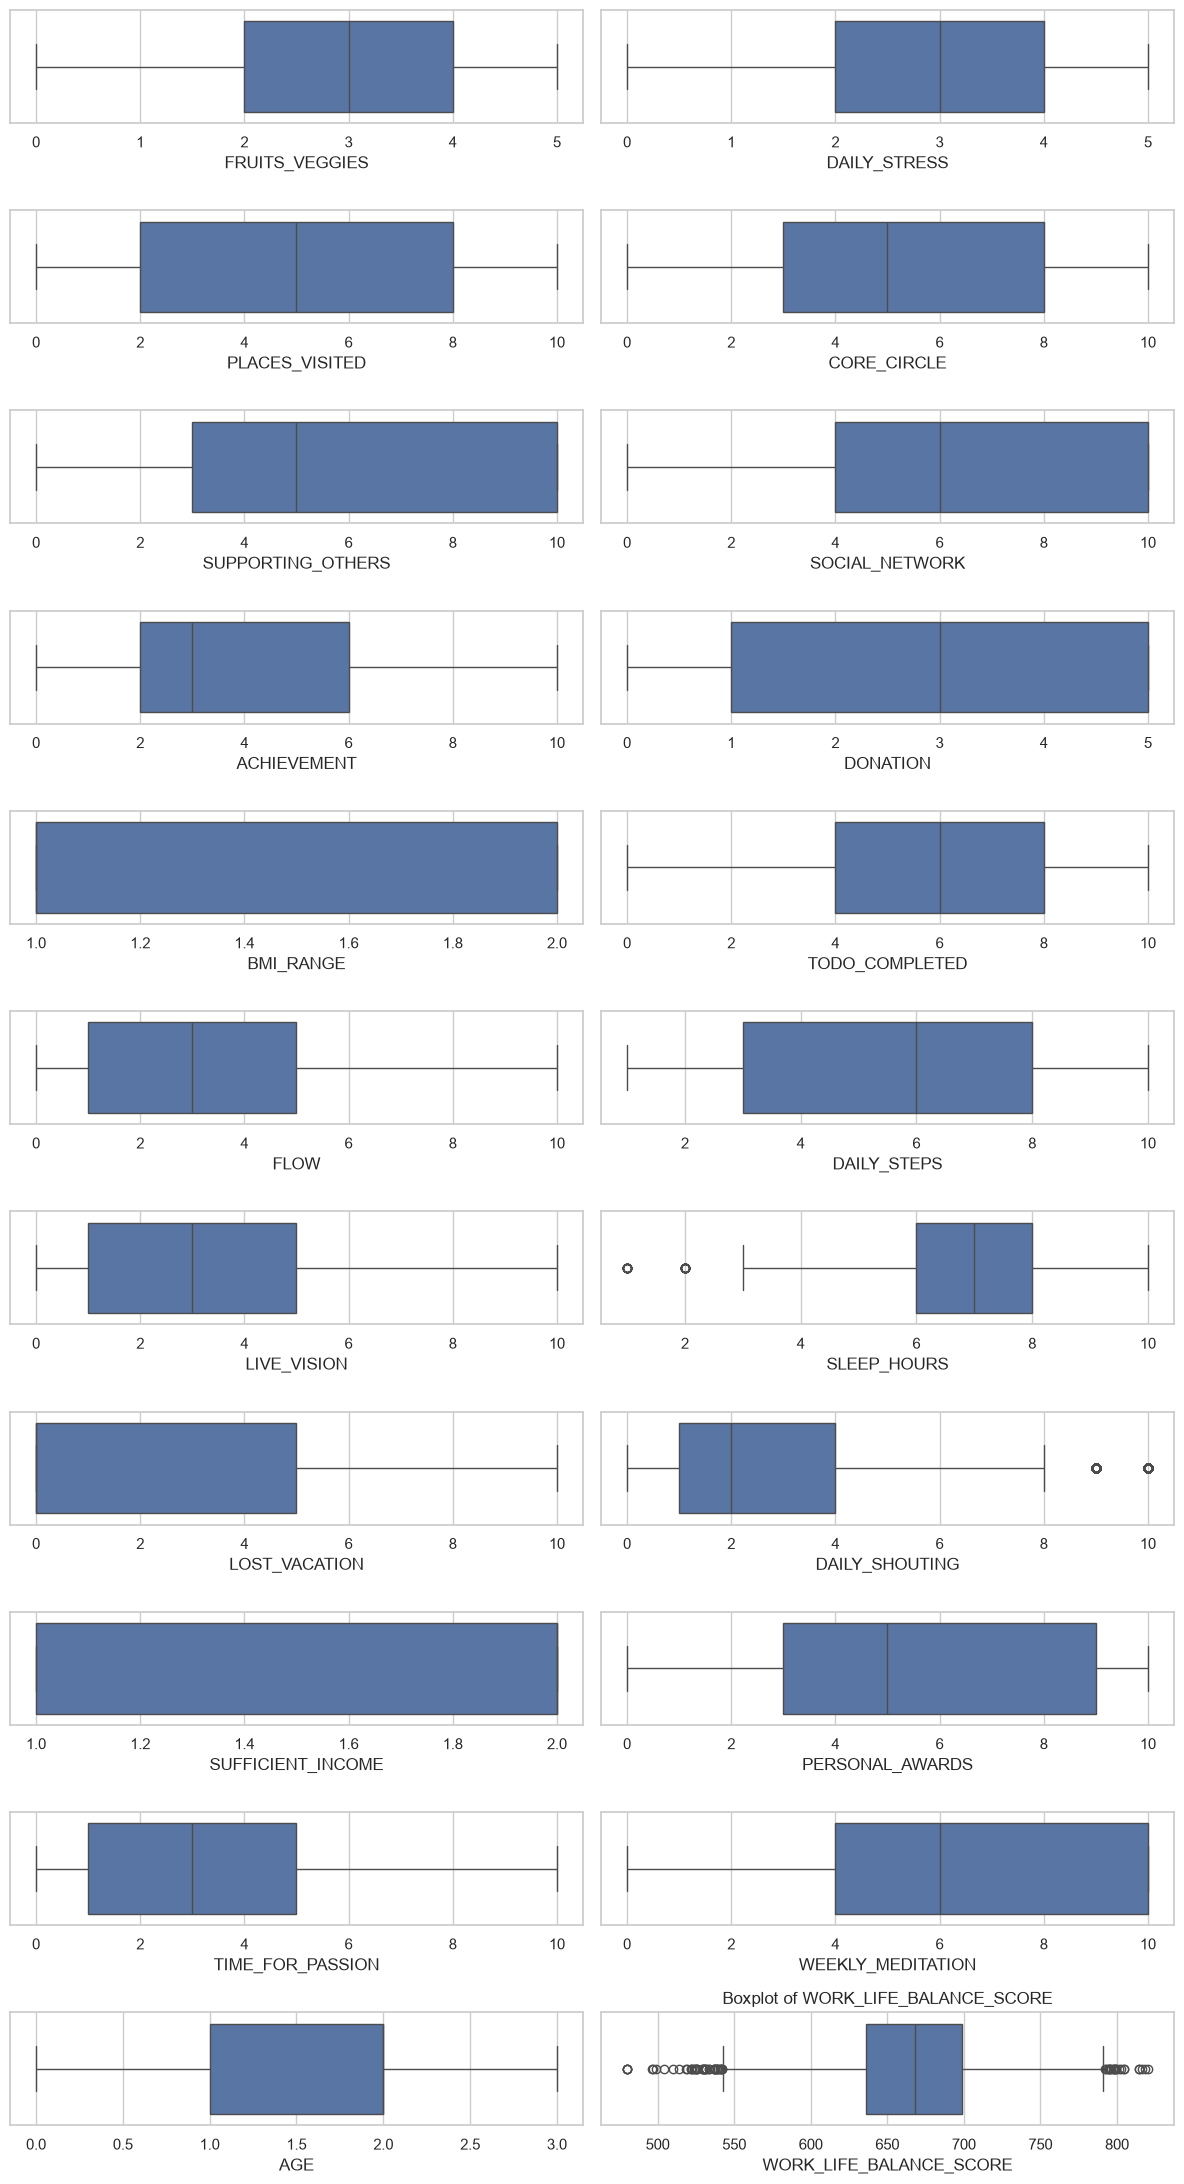

In [ ]:
numerical_features = eda_df.select_dtypes(
    include=["int64", "float64"]
).columns

fig, ax = plt.subplots(len(numerical_features)//2 + len(numerical_features) % 2, 2, figsize=(12,len(numerical_features)))
ax = ax.flatten()

for i, feature in enumerate(numerical_features):

    sns.boxplot(
        x=eda_df[feature],
        ax = ax[i]
    )

    plt.title(f"Boxplot of {feature}")

plt.tight_layout()
plt.show()